<a href="https://colab.research.google.com/github/eliza-aurora-carling/Admin/blob/main/Arrhythmia_final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ 
CIRCADIAN ARRHYTHMIA MODEL
Based on Diekman & Wei (2021), Biophysical Journal
♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ 
HEALTHY VALIDATION (g_K = 0.1 mS/cm²)


AttributeError: 'CircadianArrhythmiaModel' object has no attribute 'calculate_APD90'

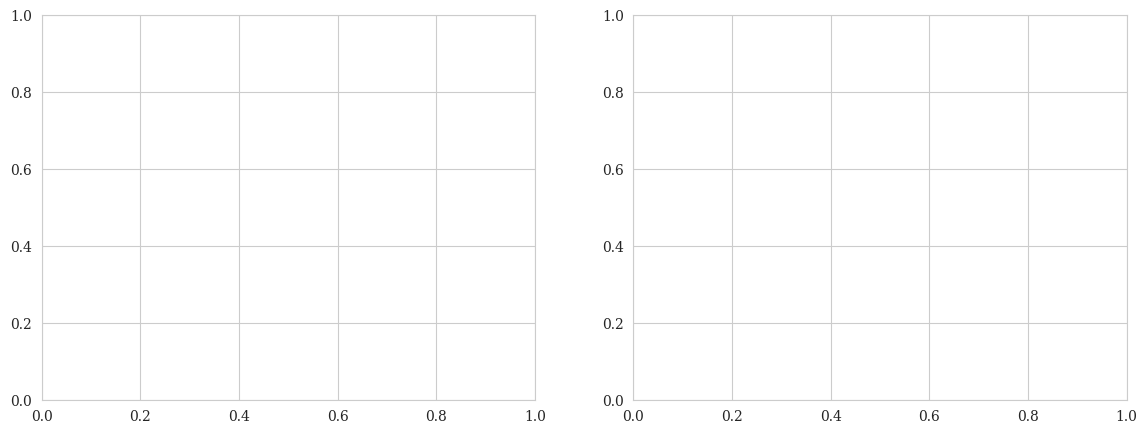

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set Times New Roman with safe fallbacks for all operating systems
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

# Define colour palette: only blues, navy, grey, black
COLORS = ['#0C1A2B', '#1B3A5C', '#2E5A88', '#4A7FB5', '#7BA3CC', '#A0A0A0', '#404040']

class CircadianArrhythmiaModel:
    """
    Modified Sato model for guinea pig ventricular myocyte with circadian
    modulation of L-type calcium conductance.

    Based on Diekman & Wei (2021), Biophysical Journal.
    """

    def __init__(self, g_K=0.1):
        # Membrane capacitance
        self.C = 1.0  # µF/cm²

        # Calcium current parameters
        self.g_CaL_base = 0.225  # mS/cm²
        self.A_CaL = 0.075       # mS/cm²
        self.E_Ca = 60           # mV
        self.theta_d = -7.3      # mV
        self.sigma_d = -8.6      # mV
        self.theta_f = -13.3     # mV
        self.sigma_f = 11.9      # mV
        self.tau_f = 80          # ms

        # Potassium current parameters
        self.g_K = g_K
        self.E_K = -80           # mV
        self.theta_x = -40       # mV
        self.sigma_x = -5        # mV
        self.tau_x = 300         # ms

        # Applied stimulus
        self.stim_duration = 2   # ms
        self.stim_amplitude = 500  # µA/cm²
        self.stim_start = 10     # ms

    def circadian_g_CaL(self, t_hour):
        phase_shift = -np.pi/2
        return self.g_CaL_base + self.A_CaL * np.sin(2 * np.pi * t_hour / 24 + phase_shift)

    def d_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_d) / self.sigma_d))

    def f_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_f) / self.sigma_f))

    def x_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_x) / self.sigma_x))

    def I_stim(self, t):
        if self.stim_start <= t <= self.stim_start + self.stim_duration:
            return self.stim_amplitude
        return 0

    def system(self, t, y, t_hour):
        V, f, x = y
        g_CaL = self.circadian_g_CaL(t_hour)
        I_CaL = g_CaL * self.d_inf(V) * f * (V - self.E_Ca)
        I_K = self.g_K * x * (V - self.E_K)
        I_app = self.I_stim(t)
        dV_dt = (I_app - I_CaL - I_K) / self.C
        df_dt = (self.f_inf(V) - f) / self.tau_f
        dx_dt = (self.x_inf(V) - x) / self.tau_x
        return [dV_dt, df_dt, dx_dt]

    def simulate_action_potential(self, t_hour, duration=1000, y0=None):
        if y0 is None:
            V0 = -80
            f0 = self.f_inf(V0)
            x0 = self.x_inf(V0)
            y0 = [V0, f0, x0]
        t_span = (0, duration)
        t_eval = np.linspace(0, duration, 5000)
        solution = solve_ivp(
            lambda t, y: self.system(t, y, t_hour),
            t_span, y0, method='RK45', t_eval=t_eval,
            rtol=1e-6, atol=1e-8
        )
        return solution.t, solution.y

    def detect_EADs(self, V, t, threshold=-20, min_peak_distance=50):
        from scipy.signal import find_peaks
        peak_idx = np.argmax(V)
        if peak_idx is None:
            return False
        V_repol = V[peak_idx:]
        if len(V_repol) < min_peak_distance:
            return False
        peaks, _ = find_peaks(V_repol, height=threshold, distance=min_peak_distance)
        return len(peaks) > 1

def calculate_APD90(self, V, t):
    peak_idx = np.argmax(V)
    V_peak = V[peak_idx]
    V_rest = np.min(V[-100:])  # Use late voltage as resting, not initial
    V_target = V_peak - 0.9 * (V_peak - V_rest)
    for i in range(peak_idx, len(V)):
        if V[i] <= V_target:
            return t[i] - t[peak_idx]
    return np.nan  # Return NaN instead of None for safer formatting

    def scan_circadian_cycle(self, hours=None, duration=1000):
        if hours is None:
            hours = np.arange(0, 24, 1)
        results = {'hours': [], 'APD90': [], 'EAD_detected': []}
        for hour in hours:
            t, y = self.simulate_action_potential(hour, duration)
            V = y[0]
            apd90 = self.calculate_APD90(V, t)
            ead = self.detect_EADs(V, t)
            results['hours'].append(hour)
            results['APD90'].append(apd90)
            results['EAD_detected'].append(ead)
        return results

    def find_steady_states(self, g_CaL, g_K, x_value):
        def steady_state_equation(V):
            f_val = self.f_inf(V)
            d_val = self.d_inf(V)
            I_CaL = g_CaL * d_val * f_val * (V - self.E_Ca)
            I_K = g_K * x_value * (V - self.E_K)
            return I_CaL + I_K
        V_range = np.linspace(-80, 60, 1000)
        roots = []
        for i in range(len(V_range) - 1):
            V1, V2 = V_range[i], V_range[i+1]
            f1 = steady_state_equation(V1)
            f2 = steady_state_equation(V2)
            if f1 * f2 < 0:
                root = fsolve(steady_state_equation, (V1 + V2)/2)[0]
                if not any(np.abs(root - r) < 1e-3 for r in roots):
                    roots.append(root)
        return sorted(roots)

    def jacobian_fast_subsystem(self, V, f, g_CaL, g_K, x_value):
        d_val = self.d_inf(V)
        d_prime = d_val * (1 - d_val) / (-self.sigma_d)
        f_val = self.f_inf(V)
        f_prime = f_val * (1 - f_val) / (-self.sigma_f)
        dF_dV = (-g_CaL * d_prime * f * (V - self.E_Ca) - g_CaL * d_val * f - g_K * x_value) / self.C
        dF_df = (-g_CaL * d_val * (V - self.E_Ca)) / self.C
        dG_dV = f_prime / self.tau_f
        dG_df = -1.0 / self.tau_f
        return np.array([[dF_dV, dF_df], [dG_dV, dG_df]])

    def find_hopf_bifurcation(self, g_CaL, g_K, x_range=None):
        if x_range is None:
            x_range = np.linspace(0.01, 1.0, 500)
        traces, determinants, x_values = [], [], []
        for x_val in x_range:
            V_roots = self.find_steady_states(g_CaL, g_K, x_val)
            if len(V_roots) >= 2:
                V_depol = max(V_roots)
                f_val = self.f_inf(V_depol)
                J = self.jacobian_fast_subsystem(V_depol, f_val, g_CaL, g_K, x_val)
                traces.append(np.real(np.trace(J)))
                determinants.append(np.real(np.linalg.det(J)))
                x_values.append(x_val)
        if len(traces) == 0:
            return None, None, None
        traces, determinants, x_values = np.array(traces), np.array(determinants), np.array(x_values)
        for i in range(len(traces) - 1):
            if traces[i] * traces[i+1] < 0 and determinants[i] > 0:
                x_HB = x_values[i] - traces[i] * (x_values[i+1] - x_values[i]) / (traces[i+1] - traces[i])
                return x_HB, x_values, traces
        return None, x_values, traces

    def compute_bifurcation_diagram(self, g_CaL, g_K, x_range=None):
        if x_range is None:
            x_range = np.linspace(0.01, 0.8, 200)
        stable_V = []
        unstable_V = []
        x_vals = []
        for x_val in x_range:
            V_roots = self.find_steady_states(g_CaL, g_K, x_val)
            for V in V_roots:
                f_val = self.f_inf(V)
                J = self.jacobian_fast_subsystem(V, f_val, g_CaL, g_K, x_val)
                eigenvals = np.linalg.eigvals(J)
                stable = np.all(np.real(eigenvals) < 0)
                if stable:
                    stable_V.append((x_val, V))
                else:
                    unstable_V.append((x_val, V))
        return stable_V, unstable_V


def run_healthy_validation():
    """Validate model with healthy parameters (g_K = 0.1)."""
    print("=" * 60)
    print("HEALTHY VALIDATION (g_K = 0.1 mS/cm²)")
    print("=" * 60)

    model = CircadianArrhythmiaModel(g_K=0.1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, hour, color in zip(axes, [3, 15], [COLORS[1], COLORS[3]]):
        t, y = model.simulate_action_potential(hour, duration=800)
        V = y[0]
        g_CaL = model.circadian_g_CaL(hour)
        apd90 = model.calculate_APD90(V, t)
        ead = model.detect_EADs(V, t)

        ax.plot(t, V, color=color, linewidth=2)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Membrane potential (mV)')
        ax.set_title(f'g_CaL = {g_CaL:.3f} mS/cm², APD90 = {apd90:.1f} ms')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 600)

        apd_str = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
        print(f"\ng_CaL = {g_CaL:.3f} mS/cm²: APD90 = {apd_str} ms, EAD = {ead}")

    plt.suptitle('Healthy condition (g_K = 0.1) with no EADs', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_healthy_validation.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_disease_progression():
    """Compare healthy vs. impaired repolarisation reserve."""
    print("\n" + "=" * 60)
    print("DISEASE PROGRESSION: Effect of reduced g_K (morning)")
    print("=" * 60)

    conditions = [(0.1, COLORS[1]), (0.05, COLORS[2]), (0.025, COLORS[0])]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, (g_K, color) in zip(axes, conditions):
        model = CircadianArrhythmiaModel(g_K=g_K)
        t, y = model.simulate_action_potential(3, duration=1000)
        V = y[0]
        g_CaL = model.circadian_g_CaL(3)
        apd90 = model.calculate_APD90(V, t)
        ead = model.detect_EADs(V, t)

        ax.plot(t, V, color=color, linewidth=2)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Membrane potential (mV)')
        ax.set_title(f'g_K = {g_K}, APD90 = {apd90:.1f} ms, EAD: {ead}')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 800)

        apd_str = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
        print(f"\ng_CaL = {g_CaL:.3f} mS/cm²: APD90 = {apd_str} ms, EAD = {ead}")

    plt.suptitle('Morning condition - risk of EADs increases with reduced g_K', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_disease_progression.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_circadian_scan():
    """Scan across 24-hour cycle for different g_K values."""
    print("\n" + "=" * 60)
    print("CIRCADIAN SCAN: APD90 Across 24 Hours")
    print("=" * 60)

    hours = np.arange(0, 24, 1)
    g_K_values = [0.1, 0.05, 0.025]
    colors = [COLORS[3], COLORS[1], COLORS[0]]

    fig, ax = plt.subplots(1, 1, figsize=(14, 6))

    for g_K, color in zip(g_K_values, colors):
        model = CircadianArrhythmiaModel(g_K=g_K)
        results = model.scan_circadian_cycle(hours)

        ax.plot(results['hours'], results['APD90'], 'o-', color=color,
                linewidth=2, markersize=6)

        # Add text annotation for EAD occurrence
        ead_hours = [h for h, e in zip(results['hours'], results['EAD_detected']) if e]
        if ead_hours:
            y_pos = np.nanmean(results['APD90']) + 50
            ax.text(ead_hours[0], y_pos, f'g_K={g_K}: EADs',
                    color=color, fontsize=10, fontweight='bold')

        print(f"\ng_K = {g_K}: EADs at hours {ead_hours}")

    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('APD90 (ms)')
    ax.set_title('Action potential duration during circadian period')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 23)

    plt.suptitle('Circadian variation in repolarisation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_circadian_scan.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_morning_vs_evening_comparison():
    """Direct comparison of morning vs evening."""
    print("\n" + "=" * 60)
    print("MORNING vs EVENING COMPARISON")
    print("=" * 60)

    g_K_values = [0.1, 0.05, 0.025]
    times = [3, 15]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    for i, g_K in enumerate(g_K_values):
        model = CircadianArrhythmiaModel(g_K=g_K)
        for j, hour in enumerate(times):
            ax = axes[j, i]
            t, y = model.simulate_action_potential(hour, duration=800)
            V = y[0]
            g_CaL = model.circadian_g_CaL(hour)
            apd90 = model.calculate_APD90(V, t)
            ead = model.detect_EADs(V, t)

            color = COLORS[0] if hour == 3 else COLORS[2]
            ax.plot(t, V, color=color, linewidth=2)
            ax.set_xlabel('Time (ms)')
            ax.set_ylabel('Membrane potential (mV)')
            ax.set_title(f'g_K = {g_K}, g_CaL = {g_CaL:.3f}\nAPD90 = {apd90:.1f} ms, EAD: {ead}')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, 600)

            print(f"g_K={g_K}, g_CaL={g_CaL:.3f}: APD90={apd90:.1f} ms, EAD={ead}")

    plt.suptitle('Morning vs evening: circadian trigger meets vulnerable substrate',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_morning_evening.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_bifurcation_analysis():
    """Generate bifurcation diagram showing Hopf bifurcation."""
    print("\n" + "=" * 60)
    print("BIFURCATION ANALYSIS: Hopf Bifurcation Detection")
    print("=" * 60)

    model = CircadianArrhythmiaModel()

    # Morning condition (high g_CaL)
    g_CaL_morning = model.circadian_g_CaL(3)
    g_K = 0.05

    print(f"\nMorning condition: g_CaL = {g_CaL_morning:.3f} mS/cm², g_K = {g_K}")

    # Find Hopf bifurcation
    x_HB, x_vals, traces = model.find_hopf_bifurcation(g_CaL_morning, g_K)

    if x_HB is not None:
        print(f"Hopf bifurcation detected at x = {x_HB:.4f}")
    else:
        print("No Hopf bifurcation detected in scanned range")

    # Generate full bifurcation diagram
    x_range = np.linspace(0.01, 0.8, 300)
    stable_V, unstable_V = model.compute_bifurcation_diagram(g_CaL_morning, g_K, x_range)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left panel: Bifurcation diagram (V vs x)
    ax1 = axes[0]
    if stable_V:
        x_stable, V_stable = zip(*stable_V)
        ax1.plot(x_stable, V_stable, color=COLORS[3], linewidth=2)
    if unstable_V:
        x_unstable, V_unstable = zip(*unstable_V)
        ax1.plot(x_unstable, V_unstable, '--', color=COLORS[5], linewidth=2)

    if x_HB is not None:
        V_at_HB = np.interp(x_HB, x_stable, V_stable) if stable_V else 0
        ax1.scatter([x_HB], [V_at_HB], color=COLORS[0], s=100, zorder=5)
        ax1.annotate(f'Hopf\nx = {x_HB:.3f}', xy=(x_HB, V_at_HB),
                     xytext=(x_HB+0.1, V_at_HB+10), fontsize=10,
                     arrowprops=dict(arrowstyle='->', color=COLORS[0]))

    ax1.set_xlabel('Slow variable x (potassium activation)')
    ax1.set_ylabel('Membrane potential V (mV)')
    ax1.set_title(f'Bifurcation diagram (g_CaL = {g_CaL_morning:.3f}, g_K = {g_K})')
    ax1.grid(True, alpha=0.3)

    # Right panel: Trace vs x
    ax2 = axes[1]
    if x_vals is not None and traces is not None:
        ax2.plot(x_vals, traces, color=COLORS[1], linewidth=2)
        ax2.axhline(y=0, color=COLORS[5], linestyle='--', linewidth=1)
        if x_HB is not None:
            ax2.scatter([x_HB], [0], color=COLORS[0], s=100, zorder=5)
        ax2.set_xlabel('Slow variable x')
        ax2.set_ylabel('Trace of Jacobian')
        ax2.set_title('Hopf bifurcation condition: Trace = 0')
        ax2.grid(True, alpha=0.3)

    plt.suptitle('Systems analysis: EADs via Hopf Bifurcation',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_bifurcation.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_phase_portrait():
    """Generate phase portrait (V vs f) showing trajectory and nullclines."""
    print("\n" + "=" * 60)
    print("V-f Plane")
    print("=" * 60)

    model = CircadianArrhythmiaModel(g_K=0.05)
    g_CaL = model.circadian_g_CaL(3)  # Morning

    # Simulate trajectory
    t, y = model.simulate_action_potential(3, duration=800)
    V_traj, f_traj = y[0], y[1]

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Plot trajectory
    ax.plot(V_traj, f_traj, color=COLORS[0], linewidth=2)
    ax.scatter(V_traj[0], f_traj[0], color=COLORS[0], s=100, zorder=5)

    # Compute and plot V-nullcline (dV/dt = 0)
    V_range = np.linspace(-80, 40, 500)
    f_nullcline_V = []
    V_nullcline_vals = []

    for V in V_range:
        # V-nullcline: f = -g_K * x * (V - E_K) / (g_CaL * d_inf(V) * (V - E_Ca))
        # Using approximate x from trajectory
        x_approx = model.x_inf(V)
        numerator = -model.g_K * x_approx * (V - model.E_K)
        denominator = g_CaL * model.d_inf(V) * (V - model.E_Ca)
        if denominator != 0:
            f_val = numerator / denominator
            if 0 <= f_val <= 1:
                f_nullcline_V.append(V)
                V_nullcline_vals.append(f_val)

    ax.plot(f_nullcline_V, V_nullcline_vals, '--', color=COLORS[2], linewidth=2)

    # f-nullcline: f = f_inf(V)
    f_nullcline_f = [model.f_inf(V) for V in V_range]
    ax.plot(V_range, f_nullcline_f, '--', color=COLORS[3], linewidth=2)

    ax.set_xlabel('Membrane potential V (mV)')
    ax.set_ylabel('Calcium inactivation gate f')
    ax.set_title(f'(g_CaL = {g_CaL:.3f}, g_K = {model.g_K})')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-80, 40)
    ax.set_ylim(0, 1)

    plt.suptitle('Trajectory and nullclines in V-f phases', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_phase_portrait.png', dpi=150, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    print("\n" + "♥ " * 30)
    print("CIRCADIAN ARRHYTHMIA MODEL")
    print("Based on Diekman & Wei (2021), Biophysical Journal")
    print("♥ " * 30)

    run_healthy_validation()
    run_disease_progression()
    run_circadian_scan()
    run_morning_vs_evening_comparison()
    run_bifurcation_analysis()
    run_phase_portrait()

    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("Figures saved:")
    print("  - arrhythmia_healthy_validation.png")
    print("  - arrhythmia_disease_progression.png")
    print("  - arrhythmia_circadian_scan.png")
    print("  - arrhythmia_morning_evening.png")
    print("  - arrhythmia_bifurcation.png")
    print("  - arrhythmia_phase_portrait.png")
    print("=" * 60)


♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ 
CIRCADIAN ARRHYTHMIA MODEL
Based on Diekman & Wei (2021), Biophysical Journal
♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ ♥ 
HEALTHY VALIDATION (g_K = 0.1 mS/cm²)

g_CaL = 0.172 mS/cm²: APD90 = N/A ms, EAD = False

g_CaL = 0.278 mS/cm²: APD90 = N/A ms, EAD = False


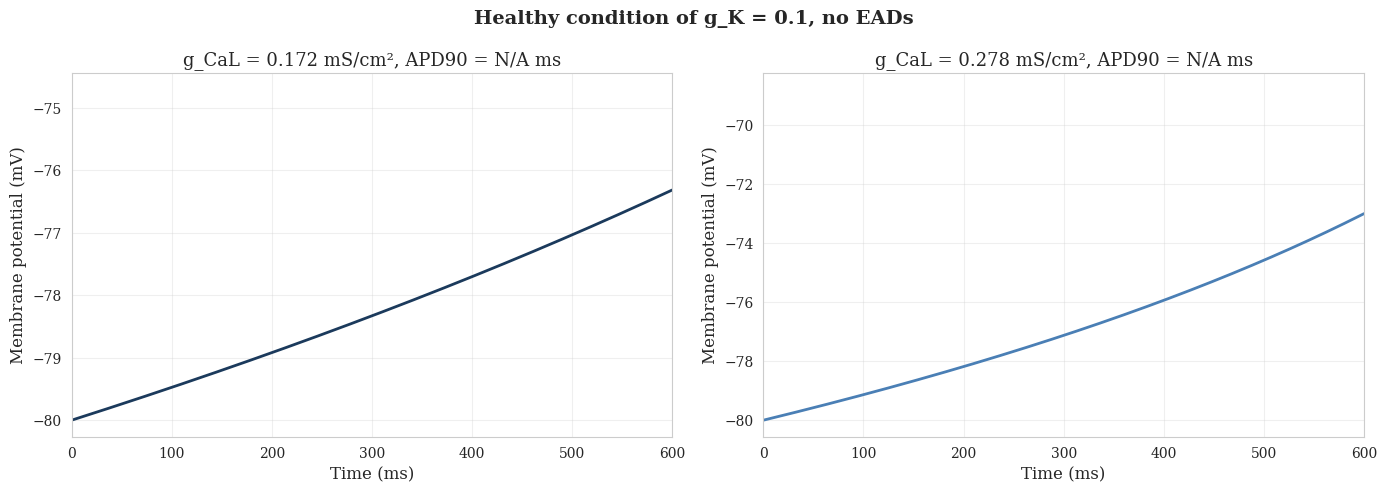


DISEASE PROGRESSION: Effect of Reduced g_K (Morning)

g_K = 0.1: APD90 = N/A ms, EAD = False

g_K = 0.05: APD90 = N/A ms, EAD = False

g_K = 0.025: APD90 = N/A ms, EAD = False


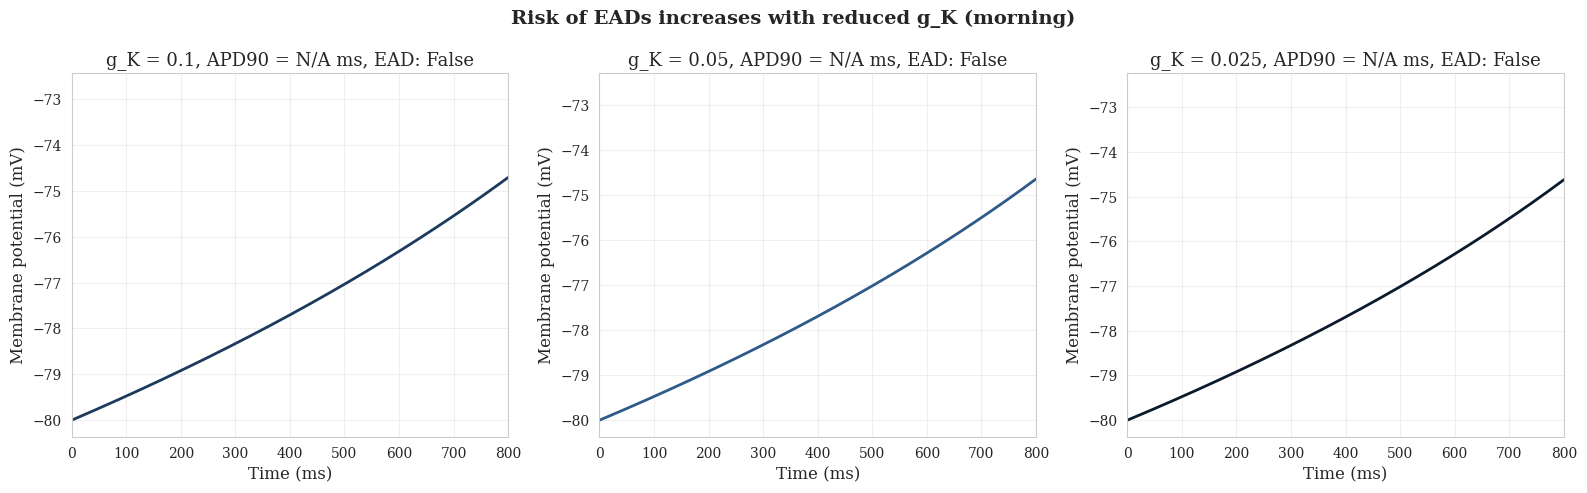


CIRCADIAN SCAN: APD90 Across 24 Hours

--- g_K = 0.1 ---
  Hour  0: max V = -69.1 mV -> NO AP FIRED
  Hour  2: max V = -67.6 mV -> NO AP FIRED
  Hour  4: max V = -62.2 mV -> NO AP FIRED
  Hour  6: max V = -43.6 mV -> NO AP FIRED
  Hour  8: max V = 48.6 mV -> APD90=160.5 ms, EAD=False
  Hour 10: max V = 51.0 mV -> APD90=175.2 ms, EAD=False
  Hour 12: max V = 51.7 mV -> APD90=178.5 ms, EAD=False
  Hour 14: max V = 51.0 mV -> APD90=175.2 ms, EAD=False
  Hour 16: max V = 48.6 mV -> APD90=160.5 ms, EAD=False
  Hour 18: max V = -43.6 mV -> NO AP FIRED
  Hour 20: max V = -62.2 mV -> NO AP FIRED
  Hour 22: max V = -67.6 mV -> NO AP FIRED
  Valid points for plotting: 5

--- g_K = 0.05 ---
  Hour  0: max V = -68.6 mV -> NO AP FIRED
  Hour  2: max V = -67.0 mV -> NO AP FIRED
  Hour  4: max V = -60.5 mV -> NO AP FIRED
  Hour  6: max V = 52.3 mV -> APD90=27.3 ms, EAD=False
  Hour  8: max V = 54.4 mV -> APD90=242.4 ms, EAD=False
  Hour 10: max V = 55.4 mV -> APD90=366.4 ms, EAD=False
  Hour 12: max

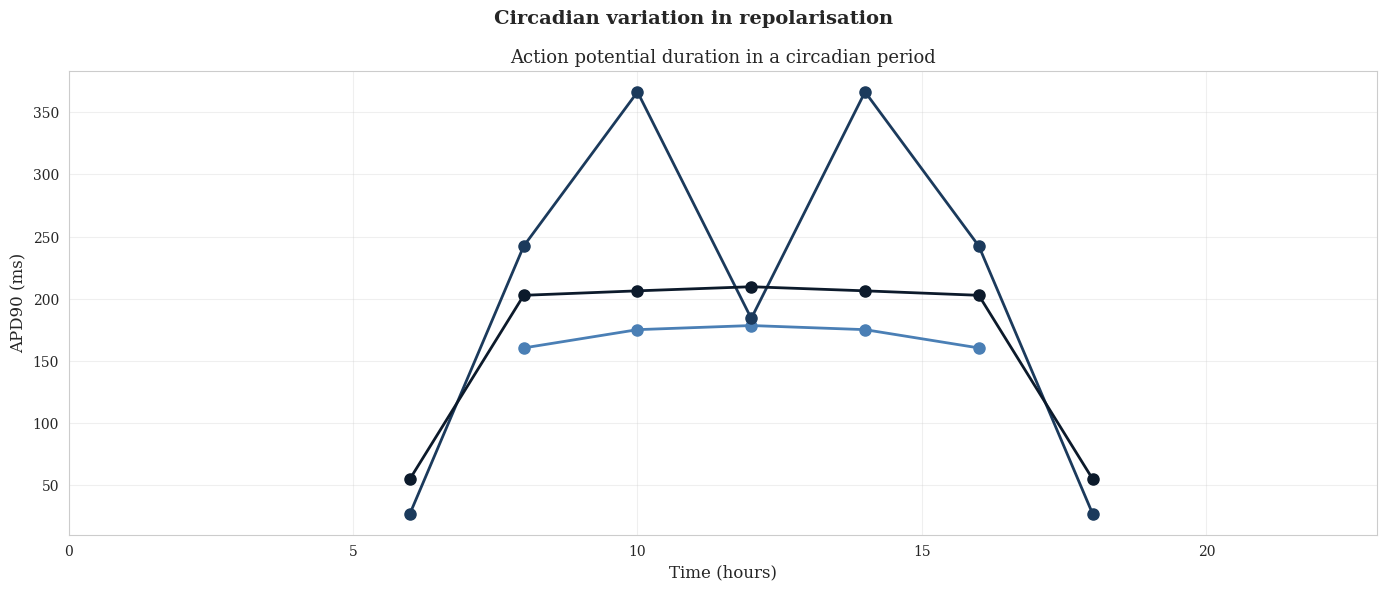


MORNING vs EVENING COMPARISON
g_K=0.1, g_CaL=0.172: APD90=N/A ms, EAD=False
g_K=0.1, g_CaL=0.278: APD90=N/A ms, EAD=False
g_K=0.05, g_CaL=0.172: APD90=N/A ms, EAD=False
g_K=0.05, g_CaL=0.278: APD90=N/A ms, EAD=False
g_K=0.025, g_CaL=0.172: APD90=N/A ms, EAD=False
g_K=0.025, g_CaL=0.278: APD90=N/A ms, EAD=False


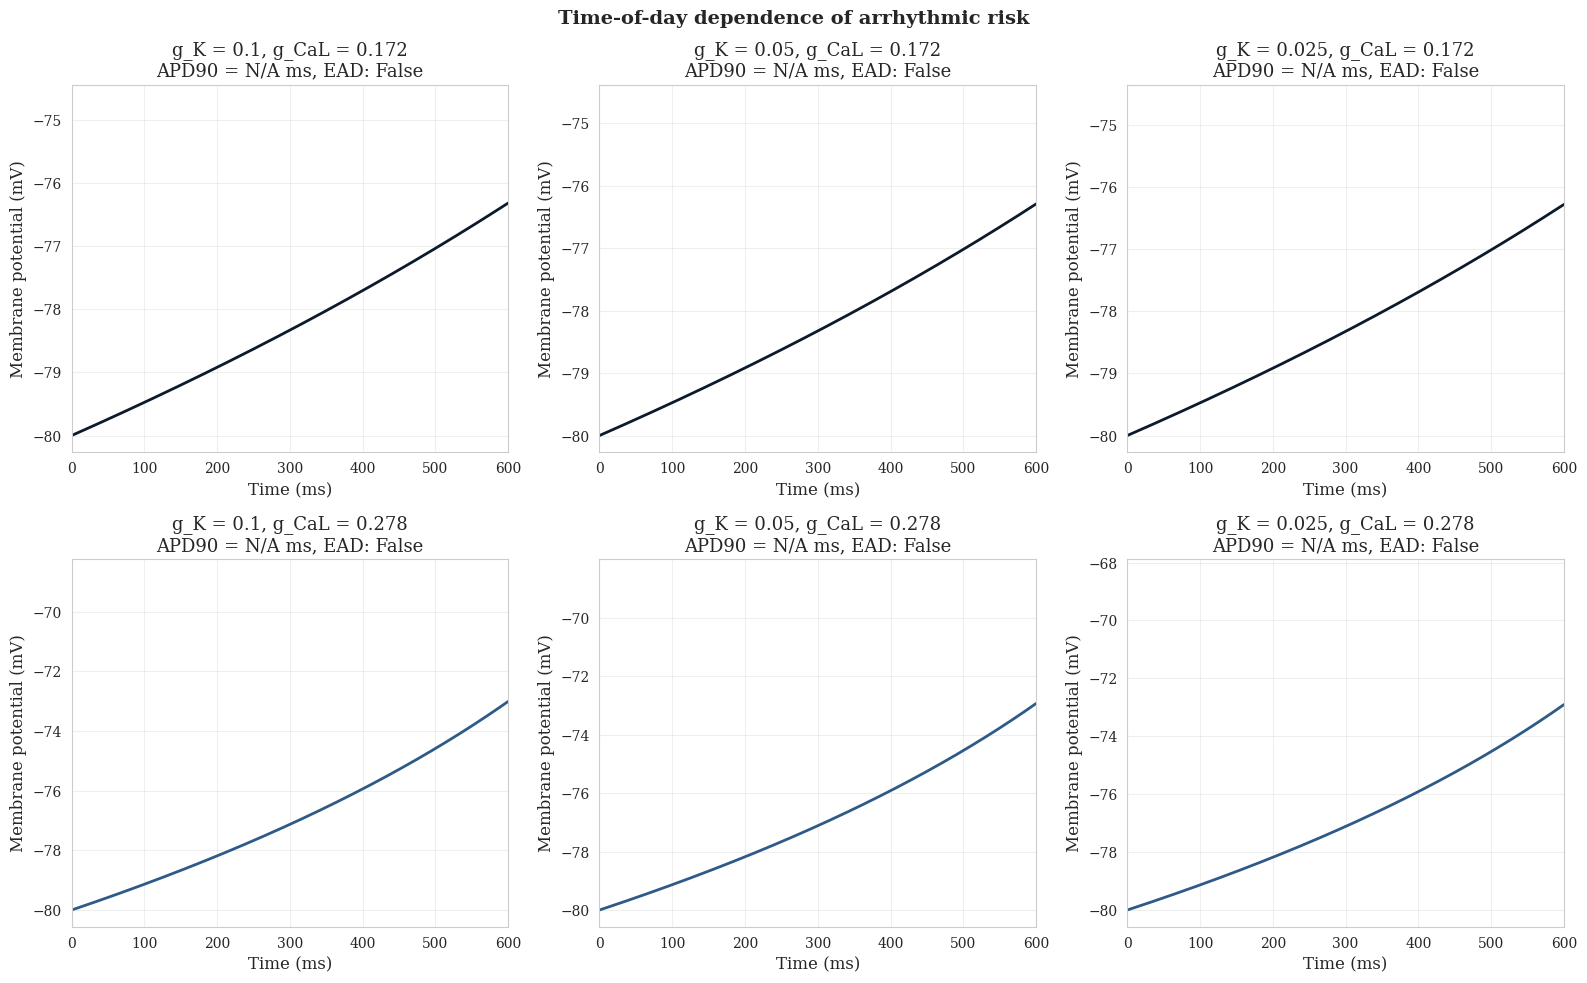


BIFURCATION ANALYSIS: Hopf Bifurcation Detection

Morning condition: g_CaL = 0.172 mS/cm², g_K = 0.05
Hopf bifurcation detected at x = 0.4556


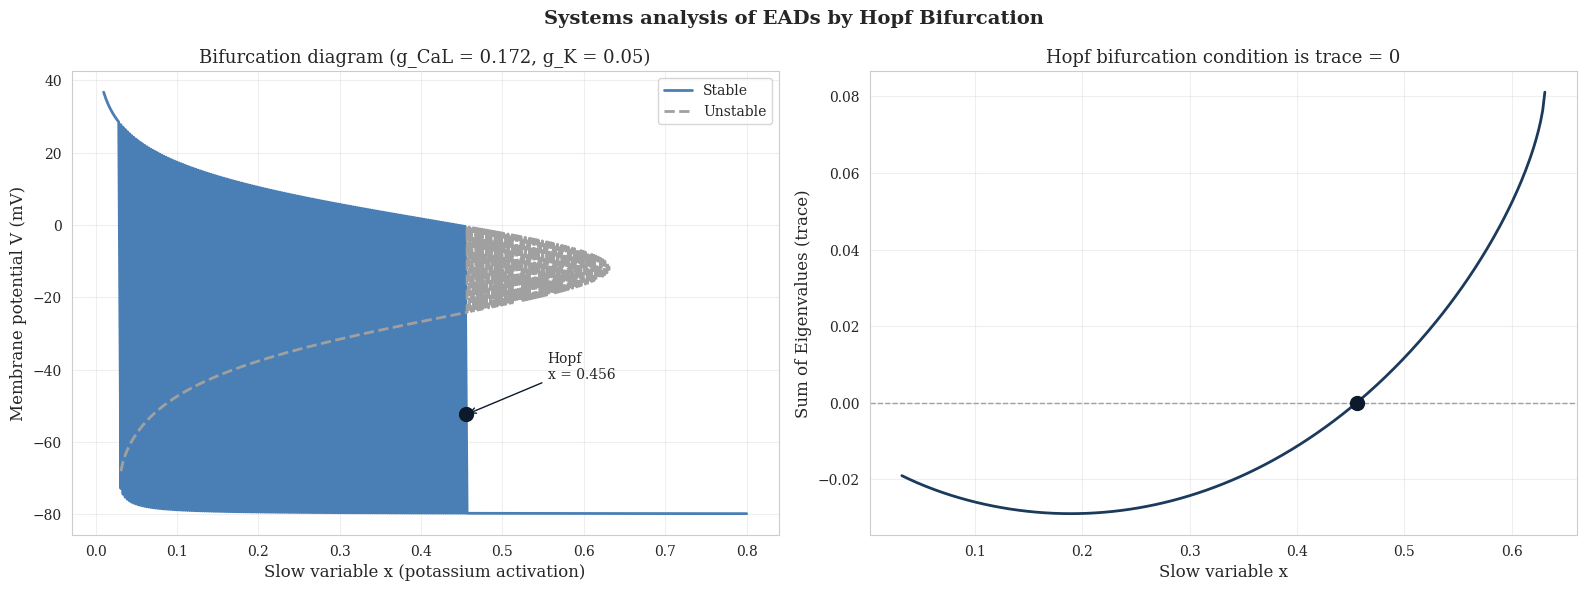


V-f Plane


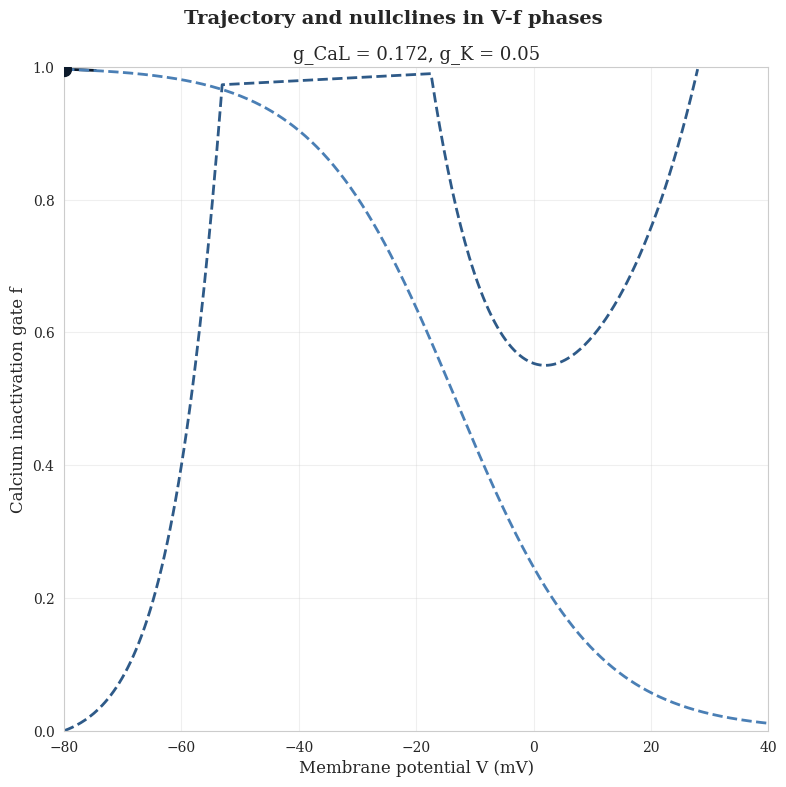


ANALYSIS COMPLETE
Figures saved:
  - arrhythmia_healthy_validation.png
  - arrhythmia_disease_progression.png
  - arrhythmia_circadian_scan.png
  - arrhythmia_morning_evening.png
  - arrhythmia_bifurcation.png
  - arrhythmia_phase_portrait.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import seaborn as sns

# First set seaborn style
sns.set_style("whitegrid")

# Then override with Times New Roman (must come AFTER seaborn)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.figsize': (12, 6)
})


# Define colour palette: only blues, navy, grey, black
COLORS = ['#0C1A2B', '#1B3A5C', '#2E5A88', '#4A7FB5', '#7BA3CC', '#A0A0A0', '#404040']


class CircadianArrhythmiaModel:
    """
    Modified Sato model for guinea pig ventricular myocyte with circadian
    modulation of L-type calcium conductance.

    Based on Diekman & Wei (2021), Biophysical Journal.
    """

    def __init__(self, g_K=0.1):
        # Membrane capacitance
        self.C = 1.0  # µF/cm²

        # Calcium current parameters
        self.g_CaL_base = 0.225  # mS/cm²
        self.A_CaL = 0.075       # mS/cm²
        self.E_Ca = 60           # mV
        self.theta_d = -7.3      # mV
        self.sigma_d = -8.6      # mV
        self.theta_f = -13.3     # mV
        self.sigma_f = 11.9      # mV
        self.tau_f = 80          # ms

        # Potassium current parameters
        self.g_K = g_K
        self.E_K = -80           # mV
        self.theta_x = -40       # mV
        self.sigma_x = -5        # mV
        self.tau_x = 300         # ms

        # Applied stimulus
        self.stim_duration = 2   # ms
        self.stim_amplitude = 500  # µA/cm²
        self.stim_start = 10     # ms

    def circadian_g_CaL(self, t_hour):
        phase_shift = -np.pi/2
        return self.g_CaL_base + self.A_CaL * np.sin(2 * np.pi * t_hour / 24 + phase_shift)

    def d_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_d) / self.sigma_d))

    def f_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_f) / self.sigma_f))

    def x_inf(self, V):
        return 1.0 / (1.0 + np.exp((V - self.theta_x) / self.sigma_x))

    def I_stim(self, t):
        if self.stim_start <= t <= self.stim_start + self.stim_duration:
            return self.stim_amplitude
        return 0

    def system(self, t, y, t_hour):
        V, f, x = y
        g_CaL = self.circadian_g_CaL(t_hour)
        I_CaL = g_CaL * self.d_inf(V) * f * (V - self.E_Ca)
        I_K = self.g_K * x * (V - self.E_K)
        I_app = self.I_stim(t)
        dV_dt = (I_app - I_CaL - I_K) / self.C
        df_dt = (self.f_inf(V) - f) / self.tau_f
        dx_dt = (self.x_inf(V) - x) / self.tau_x
        return [dV_dt, df_dt, dx_dt]

    def simulate_action_potential(self, t_hour, duration=1000, y0=None):
        if y0 is None:
            V0 = -80
            f0 = self.f_inf(V0)
            x0 = self.x_inf(V0)
            y0 = [V0, f0, x0]
        t_span = (0, duration)
        t_eval = np.linspace(0, duration, 5000)
        solution = solve_ivp(
            lambda t, y: self.system(t, y, t_hour),
            t_span, y0, method='RK45', t_eval=t_eval,
            rtol=1e-6, atol=1e-8
        )
        return solution.t, solution.y

    def detect_EADs(self, V, t, threshold=-20, min_peak_distance=50):
        from scipy.signal import find_peaks
        peak_idx = np.argmax(V)
        if peak_idx is None:
            return False
        V_repol = V[peak_idx:]
        if len(V_repol) < min_peak_distance:
            return False
        peaks, _ = find_peaks(V_repol, height=threshold, distance=min_peak_distance)
        return len(peaks) > 1

    def calculate_APD90(self, V, t):
        peak_idx = np.argmax(V)
        V_peak = V[peak_idx]
        V_rest = np.min(V[-100:])  # Use late voltage as resting, not initial
        V_target = V_peak - 0.9 * (V_peak - V_rest)
        for i in range(peak_idx, len(V)):
            if V[i] <= V_target:
                return t[i] - t[peak_idx]
        return np.nan  # Return NaN instead of None for safer formatting

    def scan_circadian_cycle(self, hours=None, duration=1000):
        if hours is None:
            hours = np.arange(0, 24, 1)
        results = {'hours': [], 'APD90': [], 'EAD_detected': []}
        for hour in hours:
            t, y = self.simulate_action_potential(hour, duration)
            V = y[0]
            apd90 = self.calculate_APD90(V, t)
            ead = self.detect_EADs(V, t)
            results['hours'].append(hour)
            results['APD90'].append(apd90)
            results['EAD_detected'].append(ead)
        return results

    def find_steady_states(self, g_CaL, g_K, x_value):
        def steady_state_equation(V):
            f_val = self.f_inf(V)
            d_val = self.d_inf(V)
            I_CaL = g_CaL * d_val * f_val * (V - self.E_Ca)
            I_K = g_K * x_value * (V - self.E_K)
            return I_CaL + I_K
        V_range = np.linspace(-80, 60, 1000)
        roots = []
        for i in range(len(V_range) - 1):
            V1, V2 = V_range[i], V_range[i+1]
            f1 = steady_state_equation(V1)
            f2 = steady_state_equation(V2)
            if f1 * f2 < 0:
                root = fsolve(steady_state_equation, (V1 + V2)/2)[0]
                if not any(np.abs(root - r) < 1e-3 for r in roots):
                    roots.append(root)
        return sorted(roots)

    def jacobian_fast_subsystem(self, V, f, g_CaL, g_K, x_value):
        d_val = self.d_inf(V)
        d_prime = d_val * (1 - d_val) / (-self.sigma_d)
        f_val = self.f_inf(V)
        f_prime = f_val * (1 - f_val) / (-self.sigma_f)
        dF_dV = (-g_CaL * d_prime * f * (V - self.E_Ca) - g_CaL * d_val * f - g_K * x_value) / self.C
        dF_df = (-g_CaL * d_val * (V - self.E_Ca)) / self.C
        dG_dV = f_prime / self.tau_f
        dG_df = -1.0 / self.tau_f
        return np.array([[dF_dV, dF_df], [dG_dV, dG_df]])

    def find_hopf_bifurcation(self, g_CaL, g_K, x_range=None):
        if x_range is None:
            x_range = np.linspace(0.01, 1.0, 500)
        traces, determinants, x_values = [], [], []
        for x_val in x_range:
            V_roots = self.find_steady_states(g_CaL, g_K, x_val)
            if len(V_roots) >= 2:
                V_depol = max(V_roots)
                f_val = self.f_inf(V_depol)
                J = self.jacobian_fast_subsystem(V_depol, f_val, g_CaL, g_K, x_val)
                traces.append(np.real(np.trace(J)))
                determinants.append(np.real(np.linalg.det(J)))
                x_values.append(x_val)
        if len(traces) == 0:
            return None, None, None
        traces, determinants, x_values = np.array(traces), np.array(determinants), np.array(x_values)
        for i in range(len(traces) - 1):
            if traces[i] * traces[i+1] < 0 and determinants[i] > 0:
                x_HB = x_values[i] - traces[i] * (x_values[i+1] - x_values[i]) / (traces[i+1] - traces[i])
                return x_HB, x_values, traces
        return None, x_values, traces

    def compute_bifurcation_diagram(self, g_CaL, g_K, x_range=None):
        if x_range is None:
            x_range = np.linspace(0.01, 0.8, 200)
        stable_V = []
        unstable_V = []
        x_vals = []
        for x_val in x_range:
            V_roots = self.find_steady_states(g_CaL, g_K, x_val)
            for V in V_roots:
                f_val = self.f_inf(V)
                J = self.jacobian_fast_subsystem(V, f_val, g_CaL, g_K, x_val)
                eigenvals = np.linalg.eigvals(J)
                stable = np.all(np.real(eigenvals) < 0)
                if stable:
                    stable_V.append((x_val, V))
                else:
                    unstable_V.append((x_val, V))
        return stable_V, unstable_V


def run_healthy_validation():
    """Validate model with healthy parameters (g_K = 0.1)."""
    print("=" * 60)
    print("HEALTHY VALIDATION (g_K = 0.1 mS/cm²)")
    print("=" * 60)

    model = CircadianArrhythmiaModel(g_K=0.1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, hour, color in zip(axes, [3, 15], [COLORS[1], COLORS[3]]):
        t, y = model.simulate_action_potential(hour, duration=800)
        V = y[0]
        g_CaL = model.circadian_g_CaL(hour)
        apd90 = model.calculate_APD90(V, t)
        ead = model.detect_EADs(V, t)

        ax.plot(t, V, color=color, linewidth=2)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Membrane potential (mV)')
        apd_str = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
        ax.set_title(f'g_CaL = {g_CaL:.3f} mS/cm², APD90 = {apd_str} ms')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 600)

        apd_print = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
        print(f"\ng_CaL = {g_CaL:.3f} mS/cm²: APD90 = {apd_print} ms, EAD = {ead}")

    plt.suptitle('Healthy condition of g_K = 0.1, no EADs', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_healthy_validation.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_disease_progression():
    """Compare healthy vs. impaired repolarisation reserve."""
    print("\n" + "=" * 60)
    print("DISEASE PROGRESSION: Effect of Reduced g_K (Morning)")
    print("=" * 60)

    conditions = [(0.1, COLORS[1]), (0.05, COLORS[2]), (0.025, COLORS[0])]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, (g_K, color) in zip(axes, conditions):
        model = CircadianArrhythmiaModel(g_K=g_K)
        t, y = model.simulate_action_potential(3, duration=1000)
        V = y[0]
        g_CaL = model.circadian_g_CaL(3)
        apd90 = model.calculate_APD90(V, t)
        ead = model.detect_EADs(V, t)

        ax.plot(t, V, color=color, linewidth=2)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Membrane potential (mV)')
        apd_str = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
        ax.set_title(f'g_K = {g_K}, APD90 = {apd_str} ms, EAD: {ead}')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 800)

        apd_print = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
        print(f"\ng_K = {g_K}: APD90 = {apd_print} ms, EAD = {ead}")

    plt.suptitle('Risk of EADs increases with reduced g_K (morning)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_disease_progression.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_circadian_scan():
    """Scan across 24-hour cycle for different g_K values."""
    print("\n" + "=" * 60)
    print("CIRCADIAN SCAN: APD90 Across 24 Hours")
    print("=" * 60)

    hours = np.arange(0, 24, 2)  # Every 2 hours for speed
    g_K_values = [0.1, 0.05, 0.025]
    colors = [COLORS[3], COLORS[1], COLORS[0]]

    fig, ax = plt.subplots(1, 1, figsize=(14, 6))

    for g_K, color in zip(g_K_values, colors):
        model = CircadianArrhythmiaModel(g_K=g_K)

        print(f"\n--- g_K = {g_K} ---")
        plot_hours = []
        plot_apd = []

        for hour in hours:
            t, y = model.simulate_action_potential(hour, duration=1500)
            V = y[0]

            max_V = np.max(V)
            print(f"  Hour {hour:2d}: max V = {max_V:.1f} mV", end="")

            if max_V < -20:
                print(" -> NO AP FIRED")
                continue  # Skip this hour entirely

            apd90 = model.calculate_APD90(V, t)
            ead = model.detect_EADs(V, t)

            if np.isnan(apd90):
                print(f" -> APD90=NaN, EAD={ead}")
                # Still include it but as NaN (won't plot)
                plot_hours.append(hour)
                plot_apd.append(np.nan)
            else:
                print(f" -> APD90={apd90:.1f} ms, EAD={ead}")
                plot_hours.append(hour)
                plot_apd.append(apd90)

        # Remove NaN values for plotting
        valid_idx = ~np.isnan(plot_apd)
        valid_hours = np.array(plot_hours)[valid_idx]
        valid_apd = np.array(plot_apd)[valid_idx]

        print(f"  Valid points for plotting: {len(valid_hours)}")

        if len(valid_hours) > 0:
            ax.plot(valid_hours, valid_apd, 'o-', color=color,
                    linewidth=2, markersize=8, label=f'g_K={g_K}')
        else:
            print(f"  WARNING: No valid APD90 values for g_K={g_K}")

    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('APD90 (ms)')
    ax.set_title('Action potential duration in a circadian period')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 23)
   # ax.legend(loc='best')

    plt.suptitle('Circadian variation in repolarisation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_circadian_scan.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_morning_vs_evening_comparison():
    """Direct comparison of morning vs evening."""
    print("\n" + "=" * 60)
    print("MORNING vs EVENING COMPARISON")
    print("=" * 60)

    g_K_values = [0.1, 0.05, 0.025]
    times = [3, 15]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    for i, g_K in enumerate(g_K_values):
        model = CircadianArrhythmiaModel(g_K=g_K)
        for j, hour in enumerate(times):
            ax = axes[j, i]
            t, y = model.simulate_action_potential(hour, duration=800)
            V = y[0]
            g_CaL = model.circadian_g_CaL(hour)
            apd90 = model.calculate_APD90(V, t)
            ead = model.detect_EADs(V, t)

            color = COLORS[0] if hour == 3 else COLORS[2]
            ax.plot(t, V, color=color, linewidth=2)
            ax.set_xlabel('Time (ms)')
            ax.set_ylabel('Membrane potential (mV)')
            apd_str = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
            ax.set_title(f'g_K = {g_K}, g_CaL = {g_CaL:.3f}\nAPD90 = {apd_str} ms, EAD: {ead}')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, 600)

            apd_print = f"{apd90:.1f}" if not np.isnan(apd90) else "N/A"
            print(f"g_K={g_K}, g_CaL={g_CaL:.3f}: APD90={apd_print} ms, EAD={ead}")

    plt.suptitle('Time-of-day dependence of arrhythmic risk',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_morning_evening.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_bifurcation_analysis():
    """Generate bifurcation diagram showing Hopf bifurcation."""
    print("\n" + "=" * 60)
    print("BIFURCATION ANALYSIS: Hopf Bifurcation Detection")
    print("=" * 60)

    model = CircadianArrhythmiaModel()

    # Morning condition (high g_CaL)
    g_CaL_morning = model.circadian_g_CaL(3)
    g_K = 0.05

    print(f"\nMorning condition: g_CaL = {g_CaL_morning:.3f} mS/cm², g_K = {g_K}")

    # Find Hopf bifurcation
    x_HB, x_vals, traces = model.find_hopf_bifurcation(g_CaL_morning, g_K)

    if x_HB is not None:
        print(f"Hopf bifurcation detected at x = {x_HB:.4f}")
    else:
        print("No Hopf bifurcation detected in scanned range")

    # Generate full bifurcation diagram
    x_range = np.linspace(0.01, 0.8, 300)
    stable_V, unstable_V = model.compute_bifurcation_diagram(g_CaL_morning, g_K, x_range)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left panel: Bifurcation diagram (V vs x)
    ax1 = axes[0]
    if stable_V:
        x_stable, V_stable = zip(*stable_V)
        ax1.plot(x_stable, V_stable, color=COLORS[3], linewidth=2, label='Stable')
    if unstable_V:
        x_unstable, V_unstable = zip(*unstable_V)
        ax1.plot(x_unstable, V_unstable, '--', color=COLORS[5], linewidth=2, label='Unstable')

    if x_HB is not None and stable_V:
        V_at_HB = np.interp(x_HB, x_stable, V_stable)
        ax1.scatter([x_HB], [V_at_HB], color=COLORS[0], s=100, zorder=5)
        ax1.annotate(f'Hopf\nx = {x_HB:.3f}', xy=(x_HB, V_at_HB),
                     xytext=(x_HB+0.1, V_at_HB+10), fontsize=10,
                     arrowprops=dict(arrowstyle='->', color=COLORS[0]))

    ax1.set_xlabel('Slow variable x (potassium activation)')
    ax1.set_ylabel('Membrane potential V (mV)')
    ax1.set_title(f'Bifurcation diagram (g_CaL = {g_CaL_morning:.3f}, g_K = {g_K})')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best')

    # Right panel: Trace vs x
    ax2 = axes[1]
    if x_vals is not None and traces is not None:
        ax2.plot(x_vals, traces, color=COLORS[1], linewidth=2)
        ax2.axhline(y=0, color=COLORS[5], linestyle='--', linewidth=1)
        if x_HB is not None:
            ax2.scatter([x_HB], [0], color=COLORS[0], s=100, zorder=5)
        ax2.set_xlabel('Slow variable x')
        ax2.set_ylabel('Sum of Eigenvalues (trace)')
        ax2.set_title('Hopf bifurcation condition is trace = 0')
        ax2.grid(True, alpha=0.3)

    plt.suptitle('Systems analysis of EADs by Hopf Bifurcation',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_bifurcation.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_phase_portrait():
    """Generate phase portrait (V vs f) showing trajectory and nullclines."""
    print("\n" + "=" * 60)
    print("V-f Plane")
    print("=" * 60)

    model = CircadianArrhythmiaModel(g_K=0.05)
    g_CaL = model.circadian_g_CaL(3)  # Morning

    # Simulate trajectory
    t, y = model.simulate_action_potential(3, duration=800)
    V_traj, f_traj = y[0], y[1]

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Plot trajectory
    ax.plot(V_traj, f_traj, color=COLORS[0], linewidth=2)
    ax.scatter(V_traj[0], f_traj[0], color=COLORS[0], s=100, zorder=5)

    # Compute and plot V-nullcline (dV/dt = 0)
    V_range = np.linspace(-80, 40, 500)
    f_nullcline_V = []
    V_nullcline_vals = []

    for V in V_range:
        # V-nullcline: f = -g_K * x * (V - E_K) / (g_CaL * d_inf(V) * (V - E_Ca))
        x_approx = model.x_inf(V)
        numerator = -model.g_K * x_approx * (V - model.E_K)
        denominator = g_CaL * model.d_inf(V) * (V - model.E_Ca)
        if denominator != 0:
            f_val = numerator / denominator
            if 0 <= f_val <= 1:
                f_nullcline_V.append(V)
                V_nullcline_vals.append(f_val)

    ax.plot(f_nullcline_V, V_nullcline_vals, '--', color=COLORS[2], linewidth=2)

    # f-nullcline: f = f_inf(V)
    f_nullcline_f = [model.f_inf(V) for V in V_range]
    ax.plot(V_range, f_nullcline_f, '--', color=COLORS[3], linewidth=2)

    ax.set_xlabel('Membrane potential V (mV)')
    ax.set_ylabel('Calcium inactivation gate f')
    ax.set_title(f'g_CaL = {g_CaL:.3f}, g_K = {model.g_K}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-80, 40)
    ax.set_ylim(0, 1)

    plt.suptitle('Trajectory and nullclines in V-f phases', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('arrhythmia_phase_portrait.png', dpi=150, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    print("\n" + "♥ " * 30)
    print("CIRCADIAN ARRHYTHMIA MODEL")
    print("Based on Diekman & Wei (2021), Biophysical Journal")
    print("♥ " * 30)

    run_healthy_validation()
    run_disease_progression()
    run_circadian_scan()
    run_morning_vs_evening_comparison()
    run_bifurcation_analysis()
    run_phase_portrait()

    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("Figures saved:")
    print("  - arrhythmia_healthy_validation.png")
    print("  - arrhythmia_disease_progression.png")
    print("  - arrhythmia_circadian_scan.png")
    print("  - arrhythmia_morning_evening.png")
    print("  - arrhythmia_bifurcation.png")
    print("  - arrhythmia_phase_portrait.png")
    print("=" * 60)